# 01 · Profiling, quality and group distributions

A strong first-pass EDA: profile the dataset, inspect missingness and variable quality, then compare full distributions across groups rather than stopping at summary statistics.

In [1]:
from pathlib import Path
import sys, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

ROOT = Path.cwd().resolve()
while not (ROOT / 'pyproject.toml').exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / 'examples' / 'notebooks'))
from _helpers import *
configure_plots()

from ruddy import analyze_univariate, analyze_distribution_diagnostics
frame, dataset = load_tabular_demo()
univ = analyze_univariate(dataset)
diag = analyze_distribution_diagnostics(dataset, responses=('activity','stability'), groups=('group','source'))
display(pd.DataFrame([univ.profiling.overview]))
display(univ.numeric_statistics[['column','mean','std','median','iqr','n_missing','n_non_finite','status']])

,n_records,n_columns,column_roles,column_kinds,column_quality,missingness,duplicates,identifier
0,180,15,"{'identifier': 1, 'variable': 6, 'response': 2...","{'numeric': 7, 'categorical': 6, 'boolean': 1,...","{'n_analysis_eligible': 14, 'n_excluded': 0, '...","{'n_missing_cells': 3, 'missing_fraction': 0.0...","{'n_duplicate_rows': 0, 'n_records_in_duplicat...","{'column': 'id', 'source': 'column', 'n_presen..."


,column,mean,std,median,iqr,n_missing,n_non_finite,status
0,activity,2.415619,1.222143,2.227261,1.911153,0,0,ok
1,stability,2.434883,0.588990,2.422966,0.766192,0,0,ok
2,length,51.831699,7.546295,52.383181,9.129493,0,0,ok
3,charge,0.115140,1.146725,0.063405,1.525425,0,0,ok
4,hydrophobicity,0.492745,0.095536,0.493877,0.136568,3,0,ok
5,nonlinear_response,1.057134,1.483522,0.582495,1.444825,0,0,ok
6,measurement,0.844374,0.852434,0.747844,1.246367,0,2,ok


## Data quality and missingness
Ruddy reports missing and non-finite values separately. The visualization layer can turn those structured counts into a compact quality overview.

findfont: Failed to find font weight semibold, now using 700.


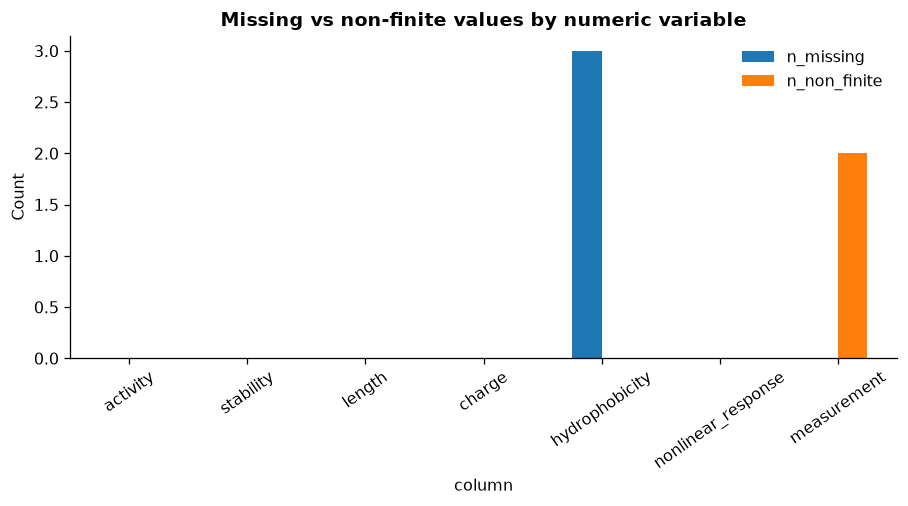

In [2]:
q = univ.numeric_statistics.set_index('column')[['n_missing','n_non_finite']]
fig, ax = plt.subplots(figsize=(8,4.5))
q.plot(kind='bar', ax=ax)
ax.set_ylabel('Count'); ax.set_title('Missing vs non-finite values by numeric variable'); ax.tick_params(axis='x', rotation=35)
finish(fig); plt.show()

## Activity distributions by group
The same response is viewed with complementary geometries: violin+box+raw observations, density, ECDF and faceted histograms.

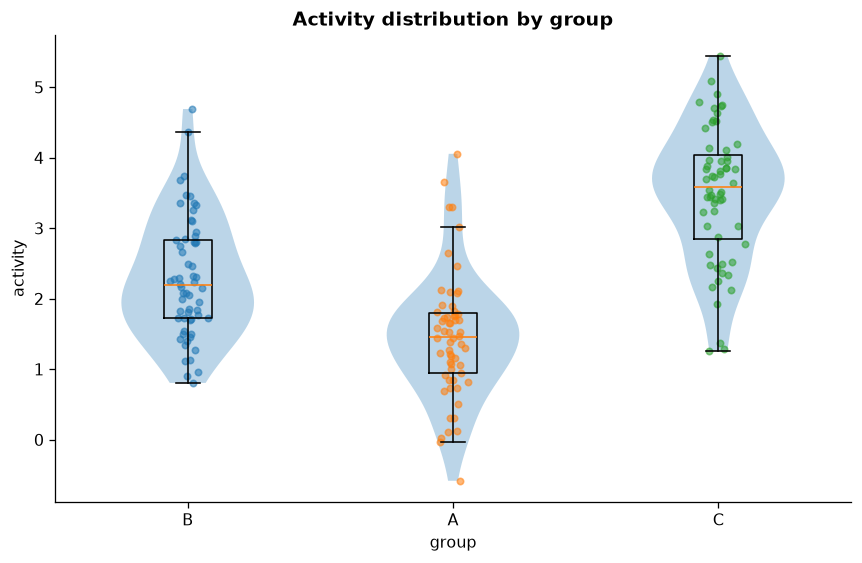

In [3]:
group_violin_box_scatter(frame, value='activity', group='group', title='Activity distribution by group'); plt.show()

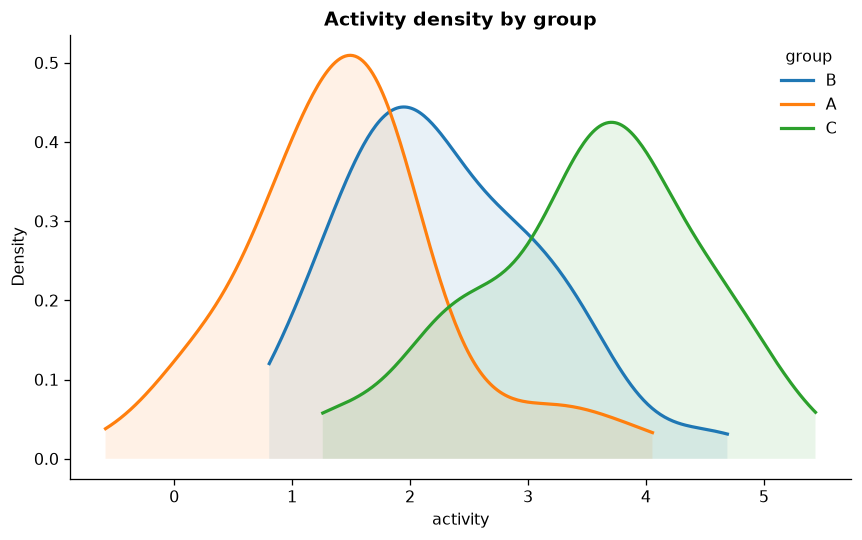

In [4]:
density_by_group(frame, value='activity', group='group', title='Activity density by group'); plt.show()

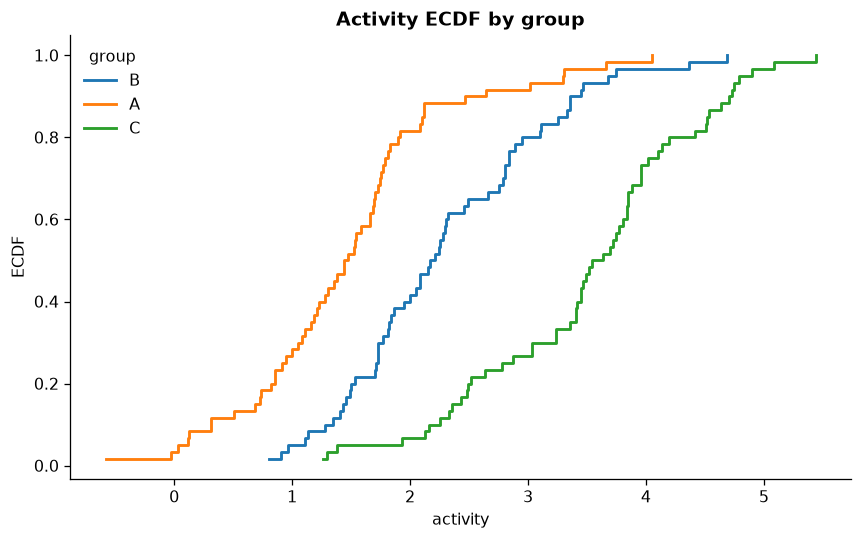

In [5]:
ecdf_by_group(frame, value='activity', group='group', title='Activity ECDF by group'); plt.show()

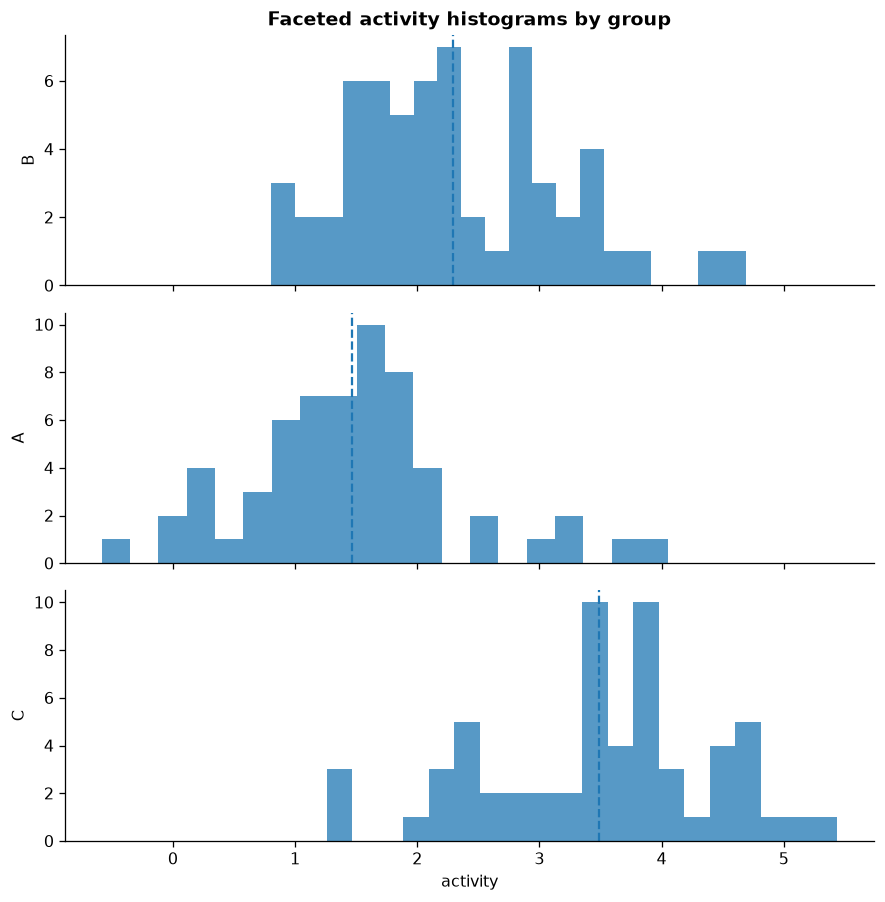

In [6]:
grouped_histograms(frame, value='activity', group='group', title='Faceted activity histograms by group'); plt.show()

## Stability by experimental source
A second response shows that group-aware visualization is not tied to one variable or one grouping factor.

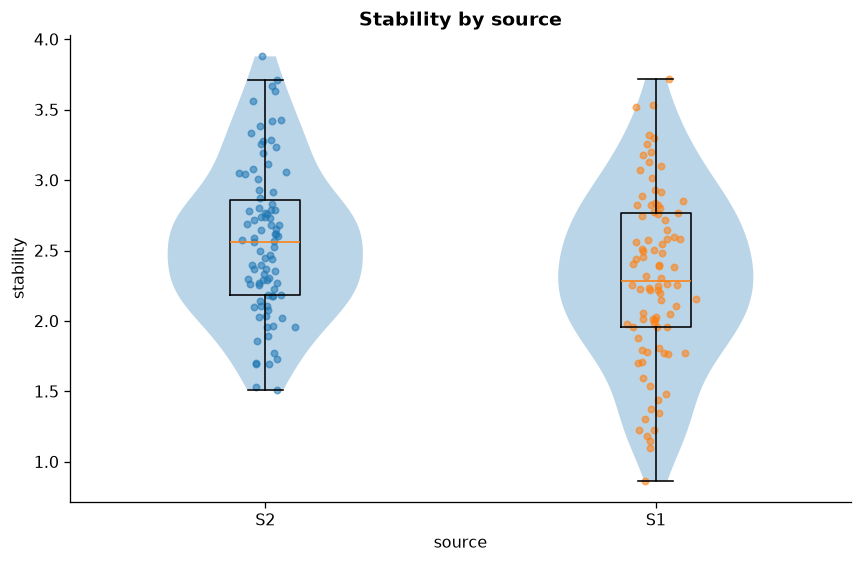

In [7]:
group_violin_box_scatter(frame, value='stability', group='source', title='Stability by source'); plt.show()

In [8]:
disp = diag.dispersion[['response','group','method','statistic','p_value','q_value','status']]
display(disp)

,response,group,method,statistic,p_value,q_value,status
0,activity,group,brown_forsythe,0.473681,0.623493,0.623493,ok
1,activity,source,brown_forsythe,5.584568,0.019198,0.038396,ok
2,stability,group,brown_forsythe,0.665236,0.515433,0.515433,ok
3,stability,source,brown_forsythe,1.827416,0.178148,0.356297,ok
4,activity,group,fligner_killeen,0.817897,0.664348,0.664348,ok
5,activity,source,fligner_killeen,4.915695,0.026614,0.053228,ok
6,stability,group,fligner_killeen,1.279844,0.527333,0.527333,ok
7,stability,source,fligner_killeen,2.044701,0.152737,0.305474,ok
